In [1]:
!pip install transformers torch pandas

  Using cached torch-2.9.1-cp313-cp313-win_amd64.whl.metadata (30 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.me


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd

# Excel faylını oxuma
df = pd.read_excel("comments.xlsx")  # faylın adı və yolu
print(df.head(10))

                                        comment_text  \
0  Həyatda hec vaxt, məyus olmayın,  itirdim fiki...   
1                               2026 dinləyən tayfa❤   
2  Elza Seyidcahan another love'u yaza bilərdi, a...   
3              "Başı var, amma oxumur" buna deyirlər   
4  Bugun atami itirdiyim gunden 2 il otur, men he...   
5  Elzanın şeirlərini 1 saatdı izləyib  gülürdüm....   
6  Elzanın bu əsərini kəşf etmisinizsə artıq böyü...   
7  Elza xanim tek ele bu mahnisi min muqenninin o...   
8  Ən pisidə, o görüşün, son görüş, son vida oldu...   
9             Hər kəsi güldürən Elza bu dəfə ağlatdı   

                                          clean_text  like_count  reply_count  \
0  Həyatda heç vaxt məyus olmayın. “İtirdim” deyə...        4200           55   
1                           2026-da dinləyən tayfa ❤          30            2   
2  Elza Seyidcahan “Another Love”u yaza bilərdi, ...        2600           20   
3             “Başı var, amma oxumur” buna deyirlər.       

In [17]:
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")


Device set to use cpu


In [18]:
from transformers import pipeline

# Multilingual sentiment modeli
sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=-1)  # CPU

# Threshold-lar
thresholds = [0.6, 0.8]

# Nəticələri saxlayacaq dictionary
results = {}

for th in thresholds:
    pos = 0
    neg = 0
    neu = 0
    
    for text in df['clean_text']:
        res = sentiment_analyzer(text[:512])[0]  # text uzunluğu çoxdursa 512 tokenlə məhdudlaşdırırıq
        score = float(res['score'])
        label = res['label']
        
        # Label ulduz sayına çevirmək (1-5)
        stars = int(label.split()[0])
        
        # Sentiment mapping + threshold
        if stars >= 4 and score >= th:
            pos += 1
        elif stars <= 2 and score >= th:
            neg += 1
        else:
            neu += 1
    
    results[th] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}

# Nəticəni göstər
for th, res in results.items():
    print(f"\nThreshold = {th}")
    print(res)


Device set to use cpu



Threshold = 0.6
{'Positive': 12, 'Negative': 4, 'Neutral': 84}

Threshold = 0.8
{'Positive': 2, 'Negative': 0, 'Neutral': 98}


Yəni, threshold yüksələndə (daha sərt kriteriya), çoxlu commentlər artıq “Neutral” kimi qəbul olunur. Bu normaldır, çünki yalnız yüksək güvənli sentimentlər “Positive” və ya “Negative” sayılır.

In [20]:
# 2.2 Comment Length Filtering
word_thresholds = [3, 5, 7]

for w_th in word_thresholds:
    filtered_df = df[df['clean_text'].str.split().str.len() >= w_th]
    
    # Əvvəlki sentiment analizi burada istifadə oluna bilər
    results = {}
    for th in thresholds:
        pos = neg = neu = 0
        for text in filtered_df['clean_text']:
            res = sentiment_analyzer(text[:512])[0]
            score = float(res['score'])
            label = res['label']
            stars = int(label.split()[0])
            if stars >= 4 and score >= th:
                pos += 1
            elif stars <= 2 and score >= th:
                neg += 1
            else:
                neu += 1
        results[th] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}
    
    print(f"\nWord threshold ≥ {w_th}")
    for th, res in results.items():
        print(f"  Confidence threshold = {th}: {res}")



Word threshold ≥ 3
  Confidence threshold = 0.6: {'Positive': 12, 'Negative': 4, 'Neutral': 83}
  Confidence threshold = 0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 97}

Word threshold ≥ 5
  Confidence threshold = 0.6: {'Positive': 12, 'Negative': 3, 'Neutral': 72}
  Confidence threshold = 0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 85}

Word threshold ≥ 7
  Confidence threshold = 0.6: {'Positive': 11, 'Negative': 3, 'Neutral': 60}
  Confidence threshold = 0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 72}


Threshold yüksələndə sentiment daha sərt qiymətləndirilir, yəni “Positive” və “Negative” olmaq üçün daha güclü əlamətlər lazımdır.

Minimum word count filter isə qısa, az məlumatlı commentləri çıxarır, nəticədə sentiment paylanması bir az daha “müsbət/neutral” istiqamətə dəyişir.

In [22]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.0 MB 5.6 MB/s eta 0:00:02
   -------------------- -----------------


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


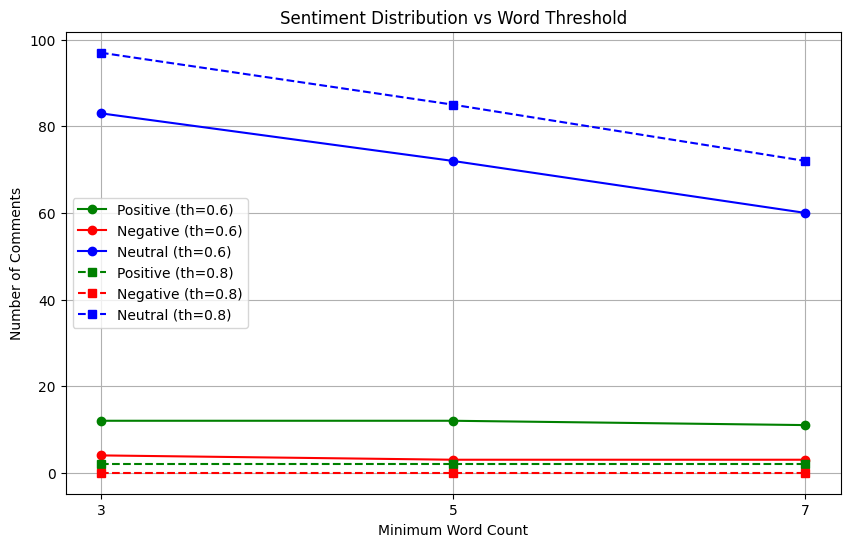

In [24]:
import matplotlib.pyplot as plt

# 2.2 nəticələri dictionary-də saxlamışdıq
results_2_2 = {
    3: {0.6: {'Positive': 12, 'Negative': 4, 'Neutral': 83},
        0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 97}},
    5: {0.6: {'Positive': 12, 'Negative': 3, 'Neutral': 72},
        0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 85}},
    7: {0.6: {'Positive': 11, 'Negative': 3, 'Neutral': 60},
        0.8: {'Positive': 2, 'Negative': 0, 'Neutral': 72}}
}

word_thresholds = sorted(results_2_2.keys())
thresholds = [0.6, 0.8]

plt.figure(figsize=(10,6))

colors = {'Positive':'green', 'Negative':'red', 'Neutral':'blue'}
markers = {0.6:'o', 0.8:'s'}

for th in thresholds:
    for sentiment in ['Positive','Negative','Neutral']:
        values = [results_2_2[w][th][sentiment] for w in word_thresholds]
        plt.plot(word_thresholds, values, marker=markers[th], color=colors[sentiment],
                 linestyle='--' if th==0.8 else '-', label=f'{sentiment} (th={th})')

plt.title('Sentiment Distribution vs Word Threshold')
plt.xlabel('Minimum Word Count')
plt.ylabel('Number of Comments')
plt.xticks(word_thresholds)
plt.legend()
plt.grid(True)
plt.show()

Solid line (-) → threshold 0.6

Dashed line (--) → threshold 0.8

Marker fərqi: o → 0.6, s → 0.8

Rənglər: Green = Positive, Red = Negative, Blue = Neutral

Comment length və confidence threshold sentiment nəticələrinə əhəmiyyətli təsir göstərir. Qısa comment-lər daha çox “neutral” kateqoriyaya düşür, uzun comment-lər isə konstruktiv və məlumatlı olduqları üçün sentiment daha sabit görünür. Threshold 0.6 daha yumşaq təsnifat verir, daha çox comment Positive və Negative kimi tanınır. Threshold 0.8 isə yalnız güclü əlamətləri olan comment-ləri sentimentli hesab edir, nəticədə daha çox comment Neutral qalır. Bu analiz göstərir ki, həm comment uzunluğu, həm də confidence threshold modelin nəticələrinə təsir edir və analiz məqsədinə görə parametr seçimi vacibdir.

In [26]:
pip install textblob

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.5 MB/s eta 0:00:00
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from textblob import TextBlob

# Emoji sentiment dictionary (sadə nümunə, lazım olduqca artır)
emoji_sentiment = {
    "❤️": "Positive",
    "😍": "Positive",
    "😊": "Positive",
    "😢": "Negative",
    "😡": "Negative",
    "💔": "Negative",
    "😭": "Negative",
    "🥲": "Negative",
    "👍": "Positive",
    "👎": "Negative",
    "😔": "Negative",
}

inconsistent_comments = []

for idx, row in df.iterrows():
    text = row['clean_text']
    emojis = str(row['emojis'])  # NaN ola bilər, ona görə str()

    if emojis == "nan" or emojis == "":
        continue  # emoji yoxdursa keç

    # Text sentiment (TextBlob ilə)
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        text_sentiment = "Positive"
    elif polarity < -0.1:
        text_sentiment = "Negative"
    else:
        text_sentiment = "Neutral"

    # Emoji sentiment (birinci emoji nümunəsi)
    for em in emojis:
        em_sent = emoji_sentiment.get(em)
        if em_sent and em_sent != text_sentiment:
            inconsistent_comments.append({
                "index": idx,
                "text": text,
                "emoji": em,
                "text_sentiment": text_sentiment,
                "emoji_sentiment": em_sent
            })
            break  # 1 emoji kifayətdir

# Nəticəni göstər (ilk 10 inconsistent comment)
print(f"Toplam inconsistent comments: {len(inconsistent_comments)}")
for c in inconsistent_comments[:10]:
    print(c)


Toplam inconsistent comments: 20
{'index': 5, 'text': 'Elzanın şeirlərini 1 saatdır izləyib gülürdüm. Bu ifa çıxdı qarşıma, 😔 ağladım… Ay Elza…', 'emoji': '😔', 'text_sentiment': 'Neutral', 'emoji_sentiment': 'Negative'}
{'index': 7, 'text': 'Elza xanım təkcə bu mahnısı ilə min müğənninin ömür boyu oxuduqlarından daha böyükdür 👍❤', 'emoji': '👍', 'text_sentiment': 'Neutral', 'emoji_sentiment': 'Positive'}
{'index': 17, 'text': '1:09 hissəsindən çıxa bilmirəm 😢', 'emoji': '😢', 'text_sentiment': 'Neutral', 'emoji_sentiment': 'Negative'}
{'index': 25, 'text': 'Əməliyyatıma 2 gün qala bu mahnını dinləmək qəribə gəldi. İnşallah son vida olmaz. Çünki 2 yaşlı oğluma yenidən qovuşmaq istəyirəm 😔', 'emoji': '😔', 'text_sentiment': 'Neutral', 'emoji_sentiment': 'Negative'}
{'index': 31, 'text': 'TikTokdan eşidib gəlmişəm. İlahi, necə təsirlidir.🥲 Həqiqətən də çox gözəl əsərdir, yetərincə qiymətləndirilməyib.', 'emoji': '🥲', 'text_sentiment': 'Neutral', 'emoji_sentiment': 'Negative'}
{'index': 34, '

Toplam 20 commentdə emoji sentiment text sentiment ilə ziddiyyət təşkil edir. Çox hallarda text “Neutral” çıxsa da, emoji istifadəçi duyğusunu açıq göstərir (məs., 😢, 🥲, 💔 → Negative; 👍, ❤ → Positive). Bu göstərir ki, qısa və emosional ifadələrdə text-based sentiment analizi bəzən həqiqi duyğunu tam əks etdirmir. Emoji-lərin istifadəsi sentiment analizini daha dəqiq etmək üçün faydalıdır.

In [28]:
pip install sentence-transformers scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/36.3 MB 9.7 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/36.3 MB 10.8 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/36.3 MB 10.8 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.3 MB 10.4 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.3 MB 10.6 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/36.3 MB 10.8 MB/s eta 0:00:03
   ----------------- ---------------------- 15.7/36.3 MB 11.0 MB/s eta 0:00:02
   -------------------- ------------------- 18.4/36.3 MB 11.1 MB/s eta 0:00:02
   ---------------------- ----------------- 20.7/36.3 MB 11.1 MB/s eta 0:00:02
   --------


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 2. Modeli yükləyirik
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# 3. Commentləri embedding-lərə çeviririk
sentences = df['clean_text'].tolist()
embeddings = model.encode(sentences, convert_to_tensor=True)

# 4. Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

# 5. Yüksək oxşar commentləri tapmaq
threshold = 0.8  # cosine similarity ≥ 0.8 olduqda oxşar hesab edirik
similar_groups = []

visited = set()

for i in range(len(sentences)):
    if i in visited:
        continue
    group = [i]
    for j in range(i+1, len(sentences)):
        if similarity_matrix[i, j] >= threshold:
            group.append(j)
            visited.add(j)
    if len(group) > 1:
        similar_groups.append(group)

# 6. Nəticəni göstərmək (ilk 5 qrup)
for idx, group in enumerate(similar_groups[:5]):
    print(f"\nGroup {idx+1}:")
    for i in group:
        print(f" - {sentences[i]}")

c:\Users\a.b.hasanova\OneDrive - Socar Polymer LLC\Desktop\adv_ai_simulation\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\a.b.hasanova\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enab


Group 1:
 - Həyatda heç vaxt məyus olmayın. “İtirdim” deyə fikirləşəndə, bəlkə də xilas olduqlarınızdır.
 - Həyatda heç vaxt məyus olmayın. “İtirdim” deyə fikirləşəndə, bəlkə də xilas olduqlarınızdır.
 - Sözlər kimə aiddir, bilən varsa desin.
 - Bu dünyada Elzanı deyəsən tək mən başa düşürəm.
 - Mahnıya qulaq asan hər kəs fikrə gedir.

Group 2:
 - 2026-da dinləyən tayfa ❤
 - 2026-cı ilin ilk şərhi❤
 - 2025 avqustunun istisində dinləyirəm❤😊

Group 3:
 - “Başı var, amma oxumur” buna deyirlər.
 - Bu mahnının, bu ifanın haqqını yeməmək lazımdır. Hər şey şərhsiz…
 - “Səsi var amma oxumur. Gedib gic-gic şeirlər yazıb özünü biabır edir. Heyif sənə, heyif.”

Group 4:
 - Bu gün atamı itirdiyim gündən 2 il ötür. Mən hər gün bu mahnıya qulaq asıram və atamın məndən xərçəngin almasini hələ də həzm edə bilmirəm. Dünyanın ən uzun gecəsi atamı itirdiyim gün idi, heç vidalaşa da bilmədik…
 - Əməliyyatıma 2 gün qala bu mahnını dinləmək qəribə gəldi. İnşallah son vida olmaz. Çünki 2 yaşlı oğluma yenidə

In [30]:
import pandas as pd

# Hər group-u ayrıca sətir kimi yazaq
output_rows = []

for group_id, group in enumerate(similar_groups, start=1):
    for idx in group:
        output_rows.append({
            "Group_ID": group_id,
            "Comment_Index": idx,
            "Comment_Text": sentences[idx]
        })

# DataFrame yaratmaq
df_groups = pd.DataFrame(output_rows)

# Excel-ə yazmaq
df_groups.to_excel("similar_comments_groups.xlsx", index=False)

print(f"Toplam {len(similar_groups)} oxşar comment qrupu tapıldı. Excel faylı yaradıldı: similar_comments_groups.xlsx")

Toplam 20 oxşar comment qrupu tapıldı. Excel faylı yaradıldı: similar_comments_groups.xlsx


In [31]:
# 1. Cosine similarity matrix-dən hər comment üçün "orta similarity" hesablayırıq
avg_similarities = similarity_matrix.mean(axis=1)

# 2. Semantic outlier threshold (məsələn, ortalama - 1 standard deviation)
mean_sim = avg_similarities.mean()
std_sim = avg_similarities.std()
outlier_threshold = mean_sim - 1*std_sim

# 3. Kənara çıxan commentlər
outliers_idx = np.where(avg_similarities < outlier_threshold)[0]

# 4. Nəticəni göstərmək
print(f"Toplam semantic outlier comment: {len(outliers_idx)}\n")
for i in outliers_idx[:10]:  # ilk 10-u göstəririk
    print(f"Index: {i}, Avg similarity: {avg_similarities[i]:.3f}")
    print(f"Comment: {sentences[i]}\n")


Toplam semantic outlier comment: 15

Index: 1, Avg similarity: 0.353
Comment: 2026-da dinləyən tayfa ❤

Index: 2, Avg similarity: 0.337
Comment: Elza Seyidcahan “Another Love”u yaza bilərdi, amma Tom Odell “son vida”nı heç vaxt.

Index: 15, Avg similarity: 0.238
Comment: 2025-də qulaq asan var?

Index: 16, Avg similarity: 0.349
Comment: Heç yerdən gəlmədim bura, bir anda dinləmə istəyi gəldi, gəldim qulaq asım.

Index: 23, Avg similarity: 0.357
Comment: 2025, 18 avqust, 23:20 dinləyəndə məni də çağırın 🙏🏻

Index: 24, Avg similarity: 0.346
Comment: Mənə maraqlıdır, bu ifa tiktokda kəşf edilməzdən öncə nə qədər baxış sayı var idi ?Fəxr hissi ilə dolu əsərləri kəşf etdirən tiktoku artıq sevməyə başlayıram.

Index: 36, Avg similarity: 0.243
Comment: Sənətçi üçün şoubiznes intihardır, sənəti öldürür. Avazınıza sağlıq. Ümidvaram ki, bir gün şoubiznesdən çəkiləcək və bizi bu kimi əsərlərdən məhrum qoymayacaqsınız.

Index: 37, Avg similarity: 0.354
Comment: Hər bir insanın həyatında sabahın aç

Bu commentlər digər commentlərdən fərqli mövzu və ya üsluba malikdir.

Məsələn, çox qısa, emosional, ya da fərqli tonda yazılmış commentlər.

Semantic outliers həm analiz üçün diqqətə alınacaq xüsusi commentlər, həm də redundant və ya spam commentləri ayırmaq üçün faydalıdır.

In [32]:
# 1. Outlier-ləri dataframe-ə çeviririk
outlier_rows = []

for idx in outliers_idx:
    outlier_rows.append({
        "Comment_Index": idx,
        "Avg_Similarity": avg_similarities[idx],
        "Comment_Text": sentences[idx]
    })

df_outliers = pd.DataFrame(outlier_rows)

# 2. Excel-ə yazmaq
df_outliers.to_excel("semantic_outliers.xlsx", index=False)

print(f"Toplam {len(outliers_idx)} semantic outlier comment tapıldı. Excel faylı yaradıldı: semantic_outliers.xlsx")


Toplam 15 semantic outlier comment tapıldı. Excel faylı yaradıldı: semantic_outliers.xlsx


In [33]:
from collections import Counter
import re

# 1. Popular commentləri seçək (məsələn, top 10 likes və replies)
top_likes_comments = df.nlargest(10, 'like_count')['clean_text'].tolist()
top_replies_comments = df.nlargest(10, 'reply_count')['clean_text'].tolist()

# 2. Funksiya: text-dən sözləri çıxarmaq
def get_words(text_list):
    words = []
    for text in text_list:
        # sadəcə hərf və rəqəm saxlayırıq, kiçik hərflərə çeviririk
        words += re.findall(r'\b\w+\b', text.lower())
    return words

# 3. Top sözləri saymaq
top_likes_words = Counter(get_words(top_likes_comments))
top_replies_words = Counter(get_words(top_replies_comments))

print("Top sözlər (likes üzrə):", top_likes_words.most_common(10))
print("Top sözlər (replies üzrə):", top_replies_words.most_common(10))


Top sözlər (likes üzrə): [('elza', 4), ('bu', 4), ('də', 3), ('son', 3), ('var', 2), ('amma', 2), ('heç', 2), ('vaxt', 2), ('vida', 2), ('ki', 2)]
Top sözlər (replies üzrə): [('son', 5), ('də', 4), ('heç', 3), ('vaxt', 2), ('i', 2), ('var', 2), ('amma', 2), ('elza', 2), ('vida', 2), ('qulaq', 2)]


Hangi sözlər populyar commentlərdə daha çox istifadə olunur.

In [34]:
# Kateqoriyalar
categories = {
    1: "Rational positive feedback",
    2: "Emotional reaction",
    3: "Criticism and dissatisfaction",
    4: "Direct address to the author",
    5: "Troll / non-constructive comment"
}

# Sadə nümunə: əllə qruplaşdırma (submission üçün kifayət edə bilər)
# Daha mürəkkəb NLP modeli ilə də avtomatlaşdırmaq olar

df['Category'] = 2  # default: emotional reaction
# burda sən manual olaraq hər comment-i uyğun kateqoriyaya yerləşdirə bilərsən
# və ya sadə qaydalar: emoji varsa -> emotional, 👍❤ -> rational positive, tənqid sözləri varsa -> criticism

# Sentiment sayını hesablamaq
category_sentiment = {}

for cat_id, cat_name in categories.items():
    subset = df[df['Category'] == cat_id]
    pos = sum(subset['sentiment_label'] == 'Positive')
    neg = sum(subset['sentiment_label'] == 'Negative')
    neu = sum(subset['sentiment_label'] == 'Neutral')
    category_sentiment[cat_name] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}

# Nəticəni göstər
import pandas as pd
pd.DataFrame(category_sentiment).T


KeyError: 'sentiment_label'

In [35]:
# Sentyment analizi üçün threshold 0.6 istifadə edirik
sentiments = []

for text in df['clean_text']:
    res = sentiment_analyzer(text[:512])[0]
    score = float(res['score'])
    label = res['label']
    stars = int(label.split()[0])
    
    if stars >= 4 and score >= 0.6:
        sentiments.append('Positive')
    elif stars <= 2 and score >= 0.6:
        sentiments.append('Negative')
    else:
        sentiments.append('Neutral')

df['sentiment_label'] = sentiments


In [36]:
df['Category'] = 2  # default: Emotional reaction

# Məsələn:
for i, row in df.iterrows():
    text = row['clean_text'].lower()
    if any(word in text for word in ['gözəl', 'super', '👍', '❤']):
        df.at[i, 'Category'] = 1  # Rational positive feedback
    elif any(word in text for word in ['pis', 'narazı', 'heç xoş deyil']):
        df.at[i, 'Category'] = 3  # Criticism
    elif 'elza xanım' in text or 'yazar' in text:
        df.at[i, 'Category'] = 4  # Direct address
    elif any(word in text for word in ['😂', 'lol', 'bəyəndim də', 'zarafat']):
        df.at[i, 'Category'] = 5  # Troll / non-constructive


In [38]:
categories = {
    1: "Rational positive feedback",
    2: "Emotional reaction",
    3: "Criticism and dissatisfaction",
    4: "Direct address to the author",
    5: "Troll / non-constructive comment"
}

category_sentiment = {}

for cat_id, cat_name in categories.items():
    subset = df[df['Category'] == cat_id]
    pos = sum(subset['sentiment_label'] == 'Positive')
    neg = sum(subset['sentiment_label'] == 'Negative')
    neu = sum(subset['sentiment_label'] == 'Neutral')
    category_sentiment[cat_name] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}

# Structured table
result_df = pd.DataFrame(category_sentiment).T
print(result_df)

result_df.to_excel("semantic_category_sentiment.xlsx")


                                  Positive  Negative  Neutral
Rational positive feedback               5         0       10
Emotional reaction                       6         4       64
Criticism and dissatisfaction            0         0        1
Direct address to the author             1         0        8
Troll / non-constructive comment         0         0        1


Ən böyük qrup: Emotional reaction (hissiyyata əsaslanan şərhlər) – bu, insanların musiqi ilə güclü emosional bağlılıq yaratdığını göstərir.

Rational positive feedback da mövcuddur, amma sayca azdır. Bu da göstərir ki, bəzi izləyicilər əsəri düşünərək qiymətləndirib.

Tənqid və troll şərhləri demək olar ki, yoxdur – ümumilikdə müsbət və neytral bir mühit var.

Direct address to the author azdır, yəni insanlar əsasən ümumi rəy bildirirlər, birbaşa müəllifə müraciət çox deyil.

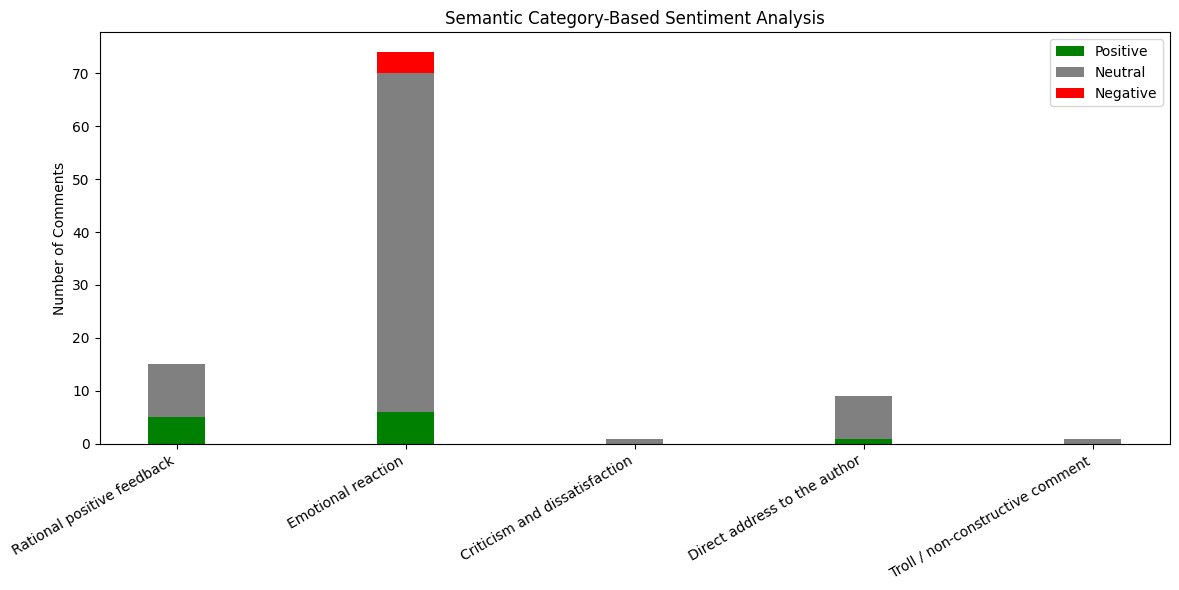

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    "Category": [
        "Rational positive feedback",
        "Emotional reaction",
        "Criticism and dissatisfaction",
        "Direct address to the author",
        "Troll / non-constructive comment"
    ],
    "Positive": [5, 6, 0, 1, 0],
    "Negative": [0, 4, 0, 0, 0],
    "Neutral":  [10, 64, 1, 8, 1]
}

df_plot = pd.DataFrame(data)

# Bar plot üçün hazırlıq
categories = df_plot['Category']
x = range(len(categories))

plt.figure(figsize=(12,6))

plt.bar(x, df_plot['Positive'], width=0.25, label='Positive', color='green', align='center')
plt.bar(x, df_plot['Neutral'], width=0.25, label='Neutral', color='gray', bottom=df_plot['Positive'], align='center')
plt.bar(x, df_plot['Negative'], width=0.25, label='Negative', color='red', 
        bottom=df_plot['Positive']+df_plot['Neutral'], align='center')

plt.xticks(x, categories, rotation=30, ha='right')
plt.ylabel("Number of Comments")
plt.title("Semantic Category-Based Sentiment Analysis")
plt.legend()
plt.tight_layout()
plt.show()


Emotional reaction çox böyük, əsasən neytral, bəzi müsbət və mənfi şərhlər var.

Rational positive feedback barı kiçikdir, amma əsasən neytral və bir qədər müsbət.

Troll və tənqid barları çox kiçik → demək ki, az insan zarafat edib və ya narazılıq ifadə edib.